In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import dinkum
from dinkum.vfg import Gene, Receptor, Ligand
from dinkum.vfn import Tissue
from dinkum import vfg, vfn

from dinkum.display import MultiTissuePanel, tc_record_activity
from dinkum.vfg2 import (Growth, Decay, LinearCombination, GeneTimecourse, LogisticActivator, run_lmfit,
                         LogisticRepressor, calc_response_1d, calc_response_2d, LogisticMultiRepressor)


import numpy as np
from itertools import chain

In [2]:
expr_df = pd.read_csv('TableS1.csv')
expr_df.rename(columns={"Gene Symbol": "gene"}, inplace=True)
expr_df = expr_df.set_index("gene")
#expr_df.set_index("Gene Symbol")

In [3]:
column_map = {}
for i in range(0, 74):
    old_name = f'{i}hpf'
    new_name = i
    column_map[old_name] = new_name

expr_df.rename(columns=column_map, inplace=True)
expr_df = expr_df.transpose()
expr_df

gene,ascl3l,mllt3,LOC575350,alx1,alx1l,LOC115922992,tfap4,arnt2,drgx,ash1l,...,LOC586893,foxj3,nsd1,xbp1l,yy1,prdm14,LOC100891209,gfi1,LOC764243,zic1
0,1,785,81,0,1,0,11,54,0,55,...,4156,4539,948,1001,1109,0,0,1,59,0
2,1,818,91,0,1,0,9,40,0,41,...,4257,4646,853,948,1166,0,0,0,66,0
4,0,852,69,0,0,5,6,50,0,47,...,4303,4524,838,937,1130,0,0,0,89,0
6,0,794,85,82,1,5,17,51,0,38,...,3638,4750,836,689,1146,0,6,1,96,0
8,0,693,64,385,0,0,78,46,0,24,...,1959,4288,749,384,1044,0,33,0,200,36
10,0,677,33,816,0,0,193,47,0,15,...,831,3255,610,310,1079,0,50,0,312,72
12,0,418,0,1031,0,0,310,18,0,5,...,417,2087,208,271,926,0,87,0,446,229
14,0,267,0,679,0,0,682,29,0,42,...,215,1734,67,470,945,0,48,6,467,348
16,2,216,3,440,4,0,887,28,0,116,...,126,1867,57,1073,1049,0,63,64,408,346
18,23,304,0,493,11,0,836,70,0,237,...,36,2031,56,1398,898,0,62,342,369,493


In [4]:
expr_df.columns

Index(['ascl3l', 'mllt3', 'LOC575350', 'alx1', 'alx1l', 'LOC115922992',
       'tfap4', 'arnt2', 'drgx', 'ash1l',
       ...
       'LOC586893', 'foxj3', 'nsd1', 'xbp1l', 'yy1', 'prdm14', 'LOC100891209',
       'gfi1', 'LOC764243', 'zic1'],
      dtype='object', name='gene', length=334)

In [5]:
expr_df.index = expr_df.index.rename('timepoint')

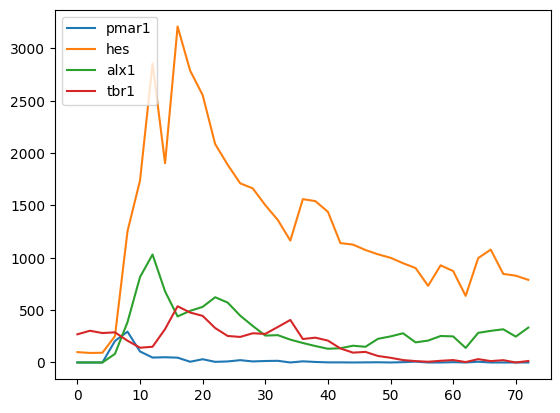

In [6]:
plt.plot(expr_df.index, expr_df.LOC115926368, label='pmar1')
plt.plot(expr_df.index, expr_df.LOC592057, label='hes')
plt.plot(expr_df.index, expr_df.alx1, label='alx1')
plt.plot(expr_df.index, expr_df.tbr1, label='tbr1')
#plt.plot(expr_df.index, expr_df.ets1, label='ets1')
plt.legend(loc='upper left')

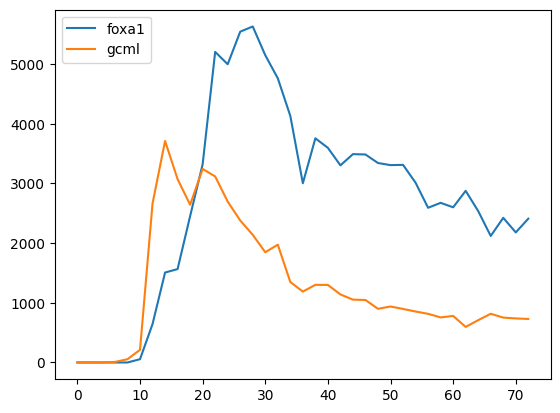

In [7]:
plt.plot(expr_df.index, expr_df.foxa1, label='foxa1') # 
plt.plot(expr_df.index, expr_df.gcml, label='gcml')
#plt.plot(expr_df.index, expr_df.alx1, label='alx1')
#plt.plot(expr_df.index, expr_df.tbr1, label='tbr1')
#plt.plot(expr_df.index, expr_df.tbr1, label='ets1')
plt.legend(loc='upper left')

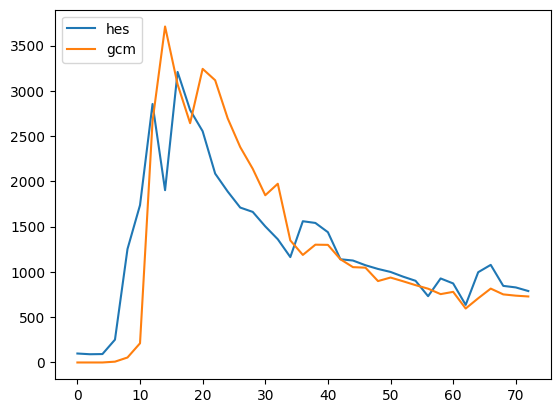

In [8]:
plt.plot(expr_df.index, expr_df.LOC592057, label='hes')
plt.plot(expr_df.index, expr_df.gcml, label='gcm')

plt.legend(loc='upper left')

In [9]:
gcm_dict = dict(expr_df[['gcml']].itertuples())
hes_dict = dict(expr_df[['LOC592057']].itertuples())
#gcm_dict

[  0.61718435 481.10863868]


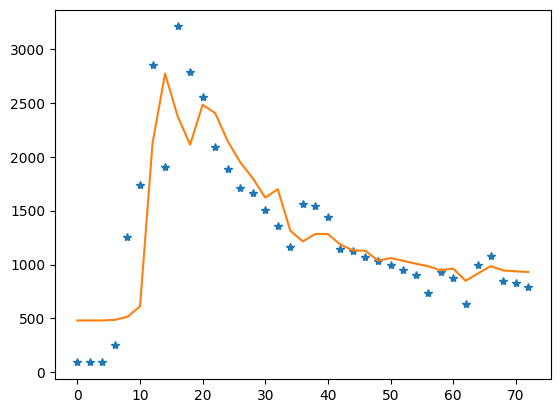

In [10]:
# run a fit to transform one data set into another

import numpy as np
from scipy.optimize import curve_fit

def hes_to_gcm(tp_list, amplitude, delay):
    assert 0 <= min(tp_list) <= 72
    assert 0 <= max(tp_list) <= 72
    assert len(tp_list) == len(gcm_dict)

    y = []
    for tp in tp_list:
        gcm_val = gcm_dict[tp]
        hes_val = gcm_val * amplitude + delay
        y.append(hes_val)

    return np.array(y)

tp_list = list(range(0, 74, 2))
popt, pcov = curve_fit(hes_to_gcm, tp_list, [ hes_dict[x] for x in tp_list ])
print(popt)

amplitude, delay = popt

fit_vals = hes_to_gcm(tp_list, amplitude, delay)

plt.plot(expr_df.index, expr_df.LOC592057, '*', label='hes')
#plt.plot(expr_df.index, expr_df.gcml, label='gcm')
plt.plot(tp_list, fit_vals, label='fit')


initializing: dinkum v0.5.0
start=1 stop=36


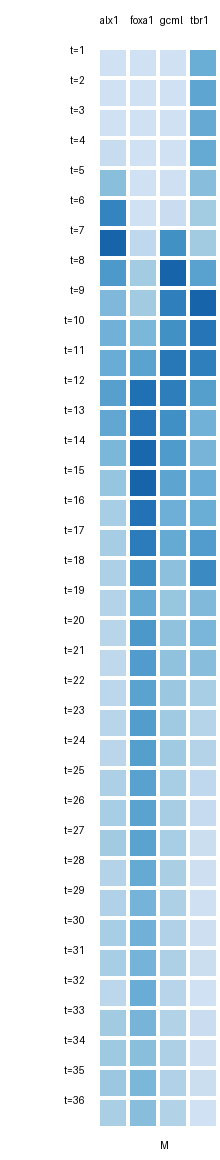

In [11]:
dinkum.reset()

alx1 = Gene(name='alx1')
tbr1 = Gene(name='tbr1')
foxa1 = Gene(name='foxa1')
gcml = Gene(name='gcml')
m = Tissue(name='M')

# load the time points into the internal dinkum structure, for given tissue
for g in (alx1, tbr1, foxa1, gcml):
    g.custom2(GeneTimecourse(start_time=1, tissue=m, values=list(expr_df[g.name])))

# NOTE: 72 hrs every 2 hrs => 36 time points
display, level_df, active_df = dinkum.run_and_display_df(start=1, stop=36)
display

/var/folders/6s/_f373w1d6hdfjc2kjstq97s80000gp/T/ipykernel_33582/2781436955.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


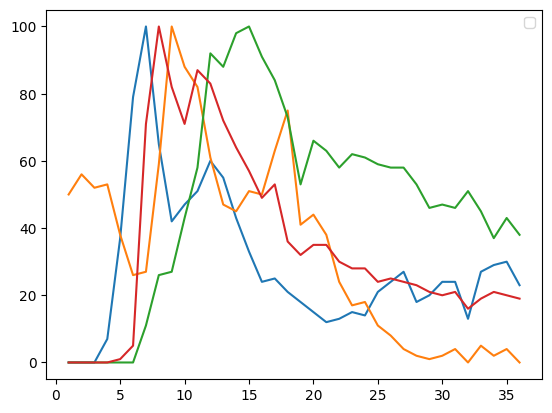

In [12]:
plt.plot(level_df.index, level_df.alx1)
plt.plot(level_df.index, level_df.tbr1)
plt.plot(level_df.index, level_df.foxa1)
plt.plot(level_df.index, level_df.gcml)
plt.legend()

initializing: dinkum v0.5.0
start=1 stop=37
fit message: Fit succeeded.
fit values:
	fit_gcm_whes: fit=0.972854227252256 (was: 1)
start=1 stop=36
[np.float64(0.972854227252256)]


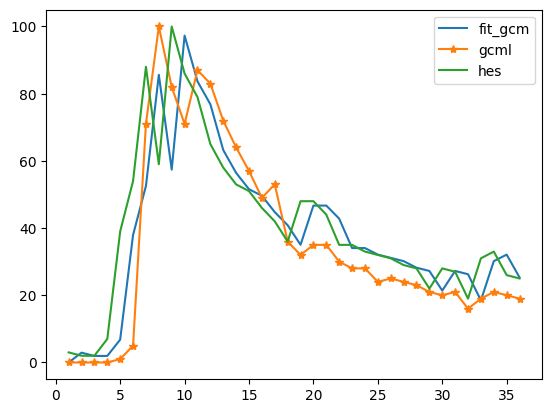

In [13]:
dinkum.reset()

alx1 = Gene(name='alx1')
tbr1 = Gene(name='tbr1')
foxa1 = Gene(name='foxa1')
gcml = Gene(name='gcml')
m = Tissue(name='M')

# load the time points into the internal dinkum structure, for given tissue
for g in (alx1, tbr1, foxa1, gcml):
    g.custom2(GeneTimecourse(start_time=1, tissue=m, values=list(expr_df[g.name])))

# hes is LOC592057...
hes = Gene(name='hes')
hes_tc = GeneTimecourse(start_time=1, tissue=m, values=list(expr_df['LOC592057']))
hes.custom2(hes_tc)

# let's see if we can fit gcml to hes (hes activates gcm)...
fit_gcm = Gene(name='fit_gcm')
fit_weights = LinearCombination(gene_names=['hes'])
fit_gcm.custom2(fit_weights)

run_lmfit(1, 37, hes_tc.values, fit_genes=[fit_gcm])

# NOTE: 72 hrs every 2 hrs => 36 time points
display, level_df, active_df = dinkum.run_and_display_df(start=1, stop=36)

plt.plot(level_df['fit_gcm'], label='fit_gcm')
plt.plot(level_df['gcml'], '*-', label='gcml')
plt.plot(level_df['hes'], label='hes')

plt.legend()
print(fit_weights.weights)

initializing: dinkum v0.5.0
start=1 stop=37
fit message: Fit succeeded.
fit values:
	fit_foxa1_whes: fit=0.8639335975295914 (was: 1)
start=1 stop=36
[np.float64(0.8639335975295914)]


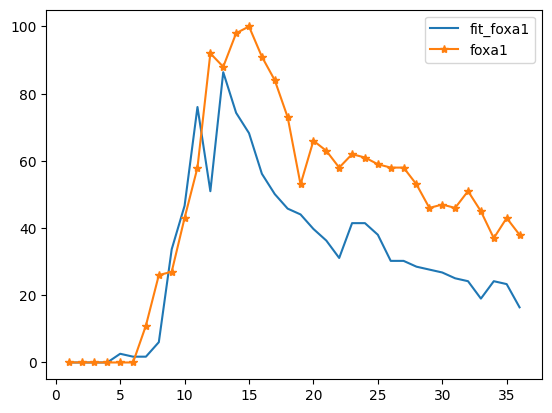

In [14]:
dinkum.reset()

alx1 = Gene(name='alx1')
tbr1 = Gene(name='tbr1')
foxa1 = Gene(name='foxa1')
gcml = Gene(name='gcml')
m = Tissue(name='M')

# load the time points into the internal dinkum structure, for given tissue
for g in (alx1, tbr1, foxa1, gcml):
    g.custom2(GeneTimecourse(start_time=1, tissue=m, values=list(expr_df[g.name])))

# hes is LOC592057...
hes = Gene(name='hes')
hes_tc = GeneTimecourse(start_time=1, tissue=m, values=list(expr_df['LOC592057']))
hes.custom2(hes_tc)

# let's see if we can fit foxa1 to hes (hes activates foxa1, too)...
fit_foxa1 = Gene(name='fit_foxa1')
fit_weights = LinearCombination(gene_names=['hes'], delay=4)
fit_foxa1.custom2(fit_weights)

run_lmfit(1, 37, hes_tc.values, fit_genes=[fit_foxa1])

# NOTE: 72 hrs every 2 hrs => 36 time points
display, level_df, active_df = dinkum.run_and_display_df(start=1, stop=36)

plt.plot(level_df['fit_foxa1'], label='fit_foxa1')
plt.plot(level_df['foxa1'], '*-', label='foxa1')
#plt.plot(level_df['hes'], label='hes')

plt.legend()
print(fit_weights.weights)

In [15]:
peak_df = pd.read_csv('tulin-s4-file.csv', sep='\t', names=['source', 'target', 'confidence'])

In [16]:
# foxa1 = 	SPU_006676
# gcml = 	SPU_006462

In [17]:
import csv

if 0:
    outfp = open('GenePageGeneralInfo_AllGenes.fix.txt', 'wt')
    with open('GenePageGeneralInfo_AllGenes.txt', 'r', newline='') as fp:
        for n, line in enumerate(fp):
            line = line.strip().split('\t')
            if len(line) != 6:
                # fix for now?
                syn = line[4] + line[5]
                line = line[:4] + [syn] + line[6:]
            print('\t'.join(line), file=outfp)
    
    outfp.close()
        

In [19]:
import csv
from collections import defaultdict

if 0:
    synonyms = defaultdict(list)
    with open('GenePageGeneralInfo_AllGenes.fix.txt', 'r', newline='') as fp:
        for n, line in enumerate(fp):
            line = line.strip().split('\t')
    
            loc = line[1]
            syn = [ x.strip() for x in line[4].split('|') ]
            for x in syn:
                if x:
                    synonyms[x].append(loc)

In [20]:
peak_df

,source,target,confidence
0,SPU_017635,SPU_005572,0.960122
1,SPU_010295,SPU_005572,0.946568
2,SPU_002320,SPU_005572,0.911574
3,SPU_003102,SPU_005572,0.889713
4,SPU_015358,SPU_005572,0.882600
...,...,...,...
15452,SPU_011174,SPU_022820,-0.846222
15453,SPU_023730,SPU_005572,-0.955081
15454,SPU_019290,SPU_005572,-0.955819
15455,SPU_011297,SPU_005572,-0.992740


In [21]:
# foxa1 = 	SPU_006676
# gcml = 	SPU_006462

print(len(peak_df[peak_df.target == 'SPU_006676']))
print(len(peak_df[peak_df.target == 'SPU_006462']))

30
30
